In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

# Create dataset $\mathcal{D} = (x, y) = (x, x^{2})$

In [3]:
def create_square_data(n):
    assert n % 2 == 0, "n must be even"

    half = n // 2

    positive = torch.arange(1, half + 1, dtype=torch.float32)
    negative = -positive

    X = torch.cat((negative, positive)).reshape(-1, 1)

    # Normalize X to [-1, 1]
    X = X / half

    # Target
    y = X ** 2

    return X, y


X, y = create_square_data(100)

In [4]:
X, y = create_square_data(100)


In [5]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(X, y)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False
)

In [6]:
for X_batch, y_batch in train_loader:
    print("X batch:")
    print(X_batch)

    print("y batch:")
    print(y_batch)

    break

X batch:
tensor([[-0.4000],
        [-0.1000]])
y batch:
tensor([[0.1600],
        [0.0100]])


___

# Create the naive model: Single perceptron node

# Model: $\hat{y} \leftarrow f_{\theta} (x)$

# Parameter: $\theta = \{ w_{1}^{1}, b_{1}^{1} \}$

![Simple Architecture](https://raw.githubusercontent.com/subhash543/Deep-Learning-using-Pytorch/main/images/simple-arch.png)

In [7]:
import torch.nn as nn

class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1, 1),   # z1
            nn.ReLU(),         # a1

            nn.Linear(1, 1),   # z2
            nn.ReLU(),         # a2

            nn.Linear(1, 1),   # z3
            nn.ReLU()          # a3
        )

    def forward(self, x):
        return self.model(x)


model = Perceptron()

print(model)

Perceptron(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1, out_features=1, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1, out_features=1, bias=True)
    (5): ReLU()
  )
)


# Parameter Description: $\theta$ (6: Un-trained)

In [8]:
print("=" * 40)
print("       LAYER-WISE PARAMETERS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        layer = name.split(".")[1]
        print(f"Layer {layer}: weight = {param.numel()}")

    elif "bias" in name:
        layer = name.split(".")[1]
        print(f"Layer {layer}: bias = {param.numel()}")

print("=" * 40)

       LAYER-WISE PARAMETERS
Layer 0: weight = 1
Layer 0: bias = 1
Layer 2: weight = 1
Layer 2: bias = 1
Layer 4: weight = 1
Layer 4: bias = 1


In [9]:
print("=" * 40)
print("            WEIGHTS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        print(f"{name}: {param.data}")

print()
print("=" * 40)
print("             BIASES")
print("=" * 40)

for name, param in model.named_parameters():
    if "bias" in name:
        print(f"{name}: {param.data}")

print("=" * 40)

            WEIGHTS
model.0.weight: tensor([[-0.8083]])
model.2.weight: tensor([[0.6616]])
model.4.weight: tensor([[-0.4476]])

             BIASES
model.0.bias: tensor([-0.0350])
model.2.bias: tensor([0.9220])
model.4.bias: tensor([0.2634])


In [10]:
# Hyperparameters

BATCH_SIZE = 16
LEARNING_RATE = 0.00001
EPOCHS = 100

In [11]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE
)

In [12]:
criterion = nn.MSELoss()

# Training Loop

In [13]:
for name, param in model.named_parameters():
    print(name, param.data)

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{EPOCHS}], "
            f"Loss: {avg_loss:.4f}"
        )

model.0.weight tensor([[-0.8083]])
model.0.bias tensor([-0.0350])
model.2.weight tensor([[0.6616]])
model.2.bias tensor([0.9220])
model.4.weight tensor([[-0.4476]])
model.4.bias tensor([0.2634])
Epoch [10/100], Loss: 0.2081
Epoch [20/100], Loss: 0.2081
Epoch [30/100], Loss: 0.2081
Epoch [40/100], Loss: 0.2081
Epoch [50/100], Loss: 0.2081
Epoch [60/100], Loss: 0.2081
Epoch [70/100], Loss: 0.2081
Epoch [80/100], Loss: 0.2081
Epoch [90/100], Loss: 0.2081
Epoch [100/100], Loss: 0.2081


# Parameter Description: $\theta^{*}$ (6: Trained)

In [14]:
print("=" * 40)
print("            WEIGHTS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        print(f"{name}: {param.data}")

print()
print("=" * 40)
print("             BIASES")
print("=" * 40)

for name, param in model.named_parameters():
    if "bias" in name:
        print(f"{name}: {param.data}")

print("=" * 40)

            WEIGHTS
model.0.weight: tensor([[-0.8083]])
model.2.weight: tensor([[0.6616]])
model.4.weight: tensor([[-0.4476]])

             BIASES
model.0.bias: tensor([-0.0350])
model.2.bias: tensor([0.9220])
model.4.bias: tensor([0.2634])


In [15]:
# Evaluation

model.eval()

total_squared_error = 0.0
total_absolute_error = 0.0
total_samples = 0

all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        y_pred = model(X_batch)

        all_predictions.append(y_pred)
        all_targets.append(y_batch)

        total_squared_error += torch.sum(
            (y_pred - y_batch) ** 2
        ).item()

        total_absolute_error += torch.sum(
            torch.abs(y_pred - y_batch)
        ).item()

        total_samples += y_batch.size(0)

predictions = torch.cat(all_predictions)
targets = torch.cat(all_targets)

# Metrics
mse = total_squared_error / total_samples
mae = total_absolute_error / total_samples
rmse = mse ** 0.5

ss_res = torch.sum((targets - predictions) ** 2)
ss_tot = torch.sum((targets - targets.mean()) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("=" * 40)
print("          MODEL PERFORMANCE")
print("=" * 40)
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2.item():.6f}")
print("=" * 40)

          MODEL PERFORMANCE
MSE  : 0.218297
MAE  : 0.349960
RMSE : 0.467223
R²   : -1.278076


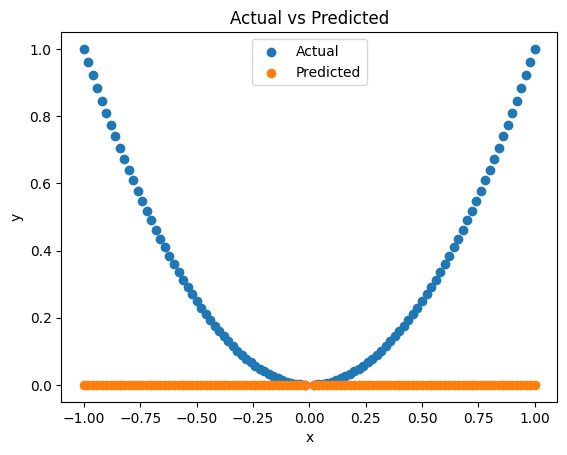

In [16]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    predictions = model(X)

plt.scatter(X, y, label="Actual")
plt.scatter(X, predictions, label="Predicted")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

___

In [17]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1, 3),
            nn.ReLU(),
            nn.Linear(3, 1)
        )

    def forward(self, x):
        return self.model(x)


model = NeuralNetwork()

print(model)

NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
)


# Parameter Description: $\theta$ (6: Un-Trained)

In [18]:
print("=" * 40)
print("       LAYER-WISE PARAMETERS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        layer = name.split(".")[1]
        print(f"Layer {layer}: weight = {param.numel()}")

    elif "bias" in name:
        layer = name.split(".")[1]
        print(f"Layer {layer}: bias = {param.numel()}")

print("=" * 40)

       LAYER-WISE PARAMETERS
Layer 0: weight = 3
Layer 0: bias = 3
Layer 2: weight = 3
Layer 2: bias = 1


In [19]:
print("=" * 40)
print("            WEIGHTS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        print(f"{name}: {param.data}")

print()
print("=" * 40)
print("             BIASES")
print("=" * 40)

for name, param in model.named_parameters():
    if "bias" in name:
        print(f"{name}: {param.data}")

print("=" * 40)

            WEIGHTS
model.0.weight: tensor([[-0.8767],
        [ 0.7126],
        [-0.0481]])
model.2.weight: tensor([[ 0.1610, -0.0756,  0.4511]])

             BIASES
model.0.bias: tensor([-0.3510,  0.0422, -0.7768])
model.2.bias: tensor([-0.0885])


In [20]:
# Hyperparameters

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 100

In [21]:
# Criterion

criterion = nn.MSELoss()

In [22]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE
)

In [23]:
for epoch in range(EPOCHS):

    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{EPOCHS}], "
            f"Loss: {avg_loss:.4f}"
        )

Epoch [10/100], Loss: 0.1180
Epoch [20/100], Loss: 0.0829
Epoch [30/100], Loss: 0.0743
Epoch [40/100], Loss: 0.0706
Epoch [50/100], Loss: 0.0677
Epoch [60/100], Loss: 0.0651
Epoch [70/100], Loss: 0.0625
Epoch [80/100], Loss: 0.0600
Epoch [90/100], Loss: 0.0575
Epoch [100/100], Loss: 0.0550


# Parameter Description: $\theta^{*}$ (6: Trained)

In [24]:
print("=" * 40)
print("            WEIGHTS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        print(f"{name}: {param.data}")

print()
print("=" * 40)
print("             BIASES")
print("=" * 40)

for name, param in model.named_parameters():
    if "bias" in name:
        print(f"{name}: {param.data}")

print("=" * 40)

            WEIGHTS
model.0.weight: tensor([[-0.9676],
        [ 0.7514],
        [-0.0481]])
model.2.weight: tensor([[0.3706, 0.2492, 0.4511]])

             BIASES
model.0.bias: tensor([-0.2585,  0.0340, -0.7768])
model.2.bias: tensor([0.2516])


In [25]:
# Evaluation

model.eval()

total_squared_error = 0.0
total_absolute_error = 0.0
total_samples = 0

all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        y_pred = model(X_batch)

        all_predictions.append(y_pred)
        all_targets.append(y_batch)

        total_squared_error += torch.sum(
            (y_pred - y_batch) ** 2
        ).item()

        total_absolute_error += torch.sum(
            torch.abs(y_pred - y_batch)
        ).item()

        total_samples += y_batch.size(0)

predictions = torch.cat(all_predictions)
targets = torch.cat(all_targets)

# Metrics
mse = total_squared_error / total_samples
mae = total_absolute_error / total_samples
rmse = mse ** 0.5

ss_res = torch.sum((targets - predictions) ** 2)
ss_tot = torch.sum((targets - targets.mean()) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("=" * 40)
print("          MODEL PERFORMANCE")
print("=" * 40)
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2.item():.6f}")
print("=" * 40)

          MODEL PERFORMANCE
MSE  : 0.056791
MAE  : 0.197930
RMSE : 0.238308
R²   : 0.407352


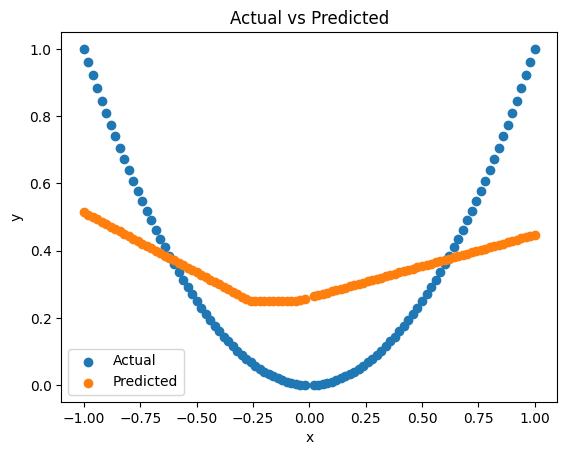

In [26]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    predictions = model(X)

plt.scatter(X, y, label="Actual")
plt.scatter(X, predictions, label="Predicted")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

___

In [27]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),

            nn.Linear(16, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)


model = NeuralNetwork()

print(model)

NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


# Parameter Description: $\theta^{*}$ (16 + 16 * 16 + 16 : Trained)

# Weights: $16 + 16 * 16 + 16 = 288$

# Bias: $ 16 + 16 + 1 = 33$

In [28]:
print("=" * 40)
print("       LAYER-WISE PARAMETERS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        layer = name.split(".")[1]
        print(f"Layer {layer}: weight = {param.numel()}")

    elif "bias" in name:
        layer = name.split(".")[1]
        print(f"Layer {layer}: bias = {param.numel()}")

print("=" * 40)

       LAYER-WISE PARAMETERS
Layer 0: weight = 16
Layer 0: bias = 16
Layer 2: weight = 256
Layer 2: bias = 16
Layer 4: weight = 16
Layer 4: bias = 1


In [29]:
print("=" * 40)
print("            WEIGHTS")
print("=" * 40)

for name, param in model.named_parameters():
    if "weight" in name:
        print(f"{name}: {param.data}")

print()
print("=" * 40)
print("             BIASES")
print("=" * 40)

for name, param in model.named_parameters():
    if "bias" in name:
        print(f"{name}: {param.data}")

print("=" * 40)

            WEIGHTS
model.0.weight: tensor([[ 0.9809],
        [-0.3398],
        [-0.2329],
        [ 0.1825],
        [-0.5208],
        [-0.7505],
        [ 0.6766],
        [ 0.3478],
        [ 0.6672],
        [-0.5593],
        [ 0.6375],
        [-0.0535],
        [ 0.9696],
        [ 0.7239],
        [-0.7508],
        [-0.1460]])
model.2.weight: tensor([[-0.0154,  0.0163,  0.1582,  0.0443,  0.2320,  0.0888, -0.0261, -0.1251,
         -0.2191, -0.0179, -0.0114, -0.0457,  0.0897, -0.0764,  0.2315,  0.1705],
        [ 0.2324,  0.2034, -0.0303,  0.0004,  0.2339, -0.1186, -0.0502, -0.1982,
         -0.0242, -0.1517, -0.0805, -0.1253,  0.1416,  0.0987, -0.2198, -0.0236],
        [ 0.0801, -0.1164,  0.2341,  0.1758, -0.0241, -0.0919, -0.1067,  0.1805,
         -0.2166, -0.1180, -0.1725, -0.0642,  0.1603,  0.0562,  0.1969,  0.2187],
        [-0.1318,  0.0111,  0.1952, -0.0410,  0.0689, -0.0653, -0.1857, -0.0274,
          0.0865, -0.1973,  0.2025,  0.0179, -0.0193, -0.0145, -0.0924, -

In [30]:
BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 100

In [31]:
criterion = nn.MSELoss()

In [32]:
EPOCHS = 1000

In [33]:
model = NeuralNetwork()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [34]:
# Training

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch [{epoch + 1}/{EPOCHS}], "
            f"Loss: {avg_loss:.6f}"
        )

Epoch [100/1000], Loss: 0.000177
Epoch [200/1000], Loss: 0.000032
Epoch [300/1000], Loss: 0.000014
Epoch [400/1000], Loss: 0.000067
Epoch [500/1000], Loss: 0.000044
Epoch [600/1000], Loss: 0.000014
Epoch [700/1000], Loss: 0.000009
Epoch [800/1000], Loss: 0.000017
Epoch [900/1000], Loss: 0.000019
Epoch [1000/1000], Loss: 0.000012


In [35]:
# Evaluation

model.eval()

total_squared_error = 0.0
total_absolute_error = 0.0
total_samples = 0

all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        y_pred = model(X_batch)

        all_predictions.append(y_pred)
        all_targets.append(y_batch)

        total_squared_error += torch.sum(
            (y_pred - y_batch) ** 2
        ).item()

        total_absolute_error += torch.sum(
            torch.abs(y_pred - y_batch)
        ).item()

        total_samples += y_batch.size(0)

predictions = torch.cat(all_predictions)
targets = torch.cat(all_targets)

# Metrics
mse = total_squared_error / total_samples
mae = total_absolute_error / total_samples
rmse = mse ** 0.5

ss_res = torch.sum((targets - predictions) ** 2)
ss_tot = torch.sum((targets - targets.mean()) ** 2)

r2 = 1 - (ss_res / ss_tot)

print("=" * 40)
print("          MODEL PERFORMANCE")
print("=" * 40)
print(f"MSE  : {mse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2.item():.6f}")
print("=" * 40)

          MODEL PERFORMANCE
MSE  : 0.000017
MAE  : 0.002993
RMSE : 0.004075
R²   : 0.999827


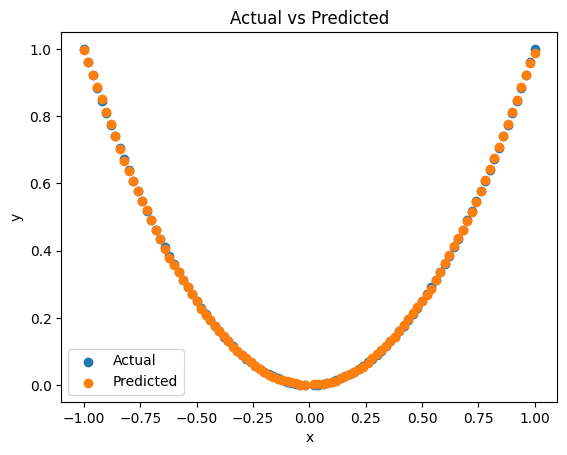

In [36]:
import matplotlib.pyplot as plt

model.eval()

with torch.no_grad():
    predictions = model(X)

plt.scatter(X, y, label="Actual")
plt.scatter(X, predictions, label="Predicted")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()